In [1]:
import numpy as np

from graphviz import Digraph
import networkx as nx
import networkx.algorithms as nxa
import re

import DeBruijnDNA
import AcyclicGraphDNA

import matplotlib.pyplot as plt
from dwave.samplers import SimulatedAnnealingSampler

from collections import defaultdict

import sys
sys.path.append("../HADOFv2")

import HADOFrun

import dill as pickle

/Users/namasi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def solve_dwave(Q):
    """
    Q = np.array([[-1, 1, 0], [1, -1, -2], [0, -2, -1]])
    solve_dwave(Q)
    """
    q = {}
    size = len(Q)
    for i in range(size):
        for j in range(size):
            q[(i,j)] = Q[i][j]
            
    sampler = SimulatedAnnealingSampler()
    response = sampler.sample_qubo(q, num_reads=5000, anneal_time=20)

    # response = sampler.sample_qubo(q, num_reads = 5000, beta_range = [1,200], beta_schedule_type = 'linear', num_sweeps=50)

    result = []
    samples = []
    energies = []
    for sample, energy in response.data(['sample', 'energy']): 
        result.append(sample)
        result.append(energy)
    #     samples.append(sample)
    #     energies.append(energy)
    # result.append(samples[np.argmin(energies)])
    # result.append(energies[np.argmin(energies)])

    result.append(response.info) # view timings
    
    return result

Loading the String Graph

In [3]:
filename = "ERR13577262_raw_string.gfa"
segments, links, containments = AcyclicGraphDNA.load_file(filename)
segments = [l.replace(":", "/", 1) for l in segments]
links = [l.replace(":", "/", 2) for l in links]


initial_graph, adjacency_matrix, nodes_indices, nodes_labels, links_edges = AcyclicGraphDNA.get_initial_graph(segments, links)
strand_graph = AcyclicGraphDNA.get_strand_graph(initial_graph)

print('links quantity: ', len(links_edges))

segments: 524, links: 4642, containments: 0, lines: 5166

nodes quantity: 1048
links quantity:  4632


strand_adjacency_matrix size: 524


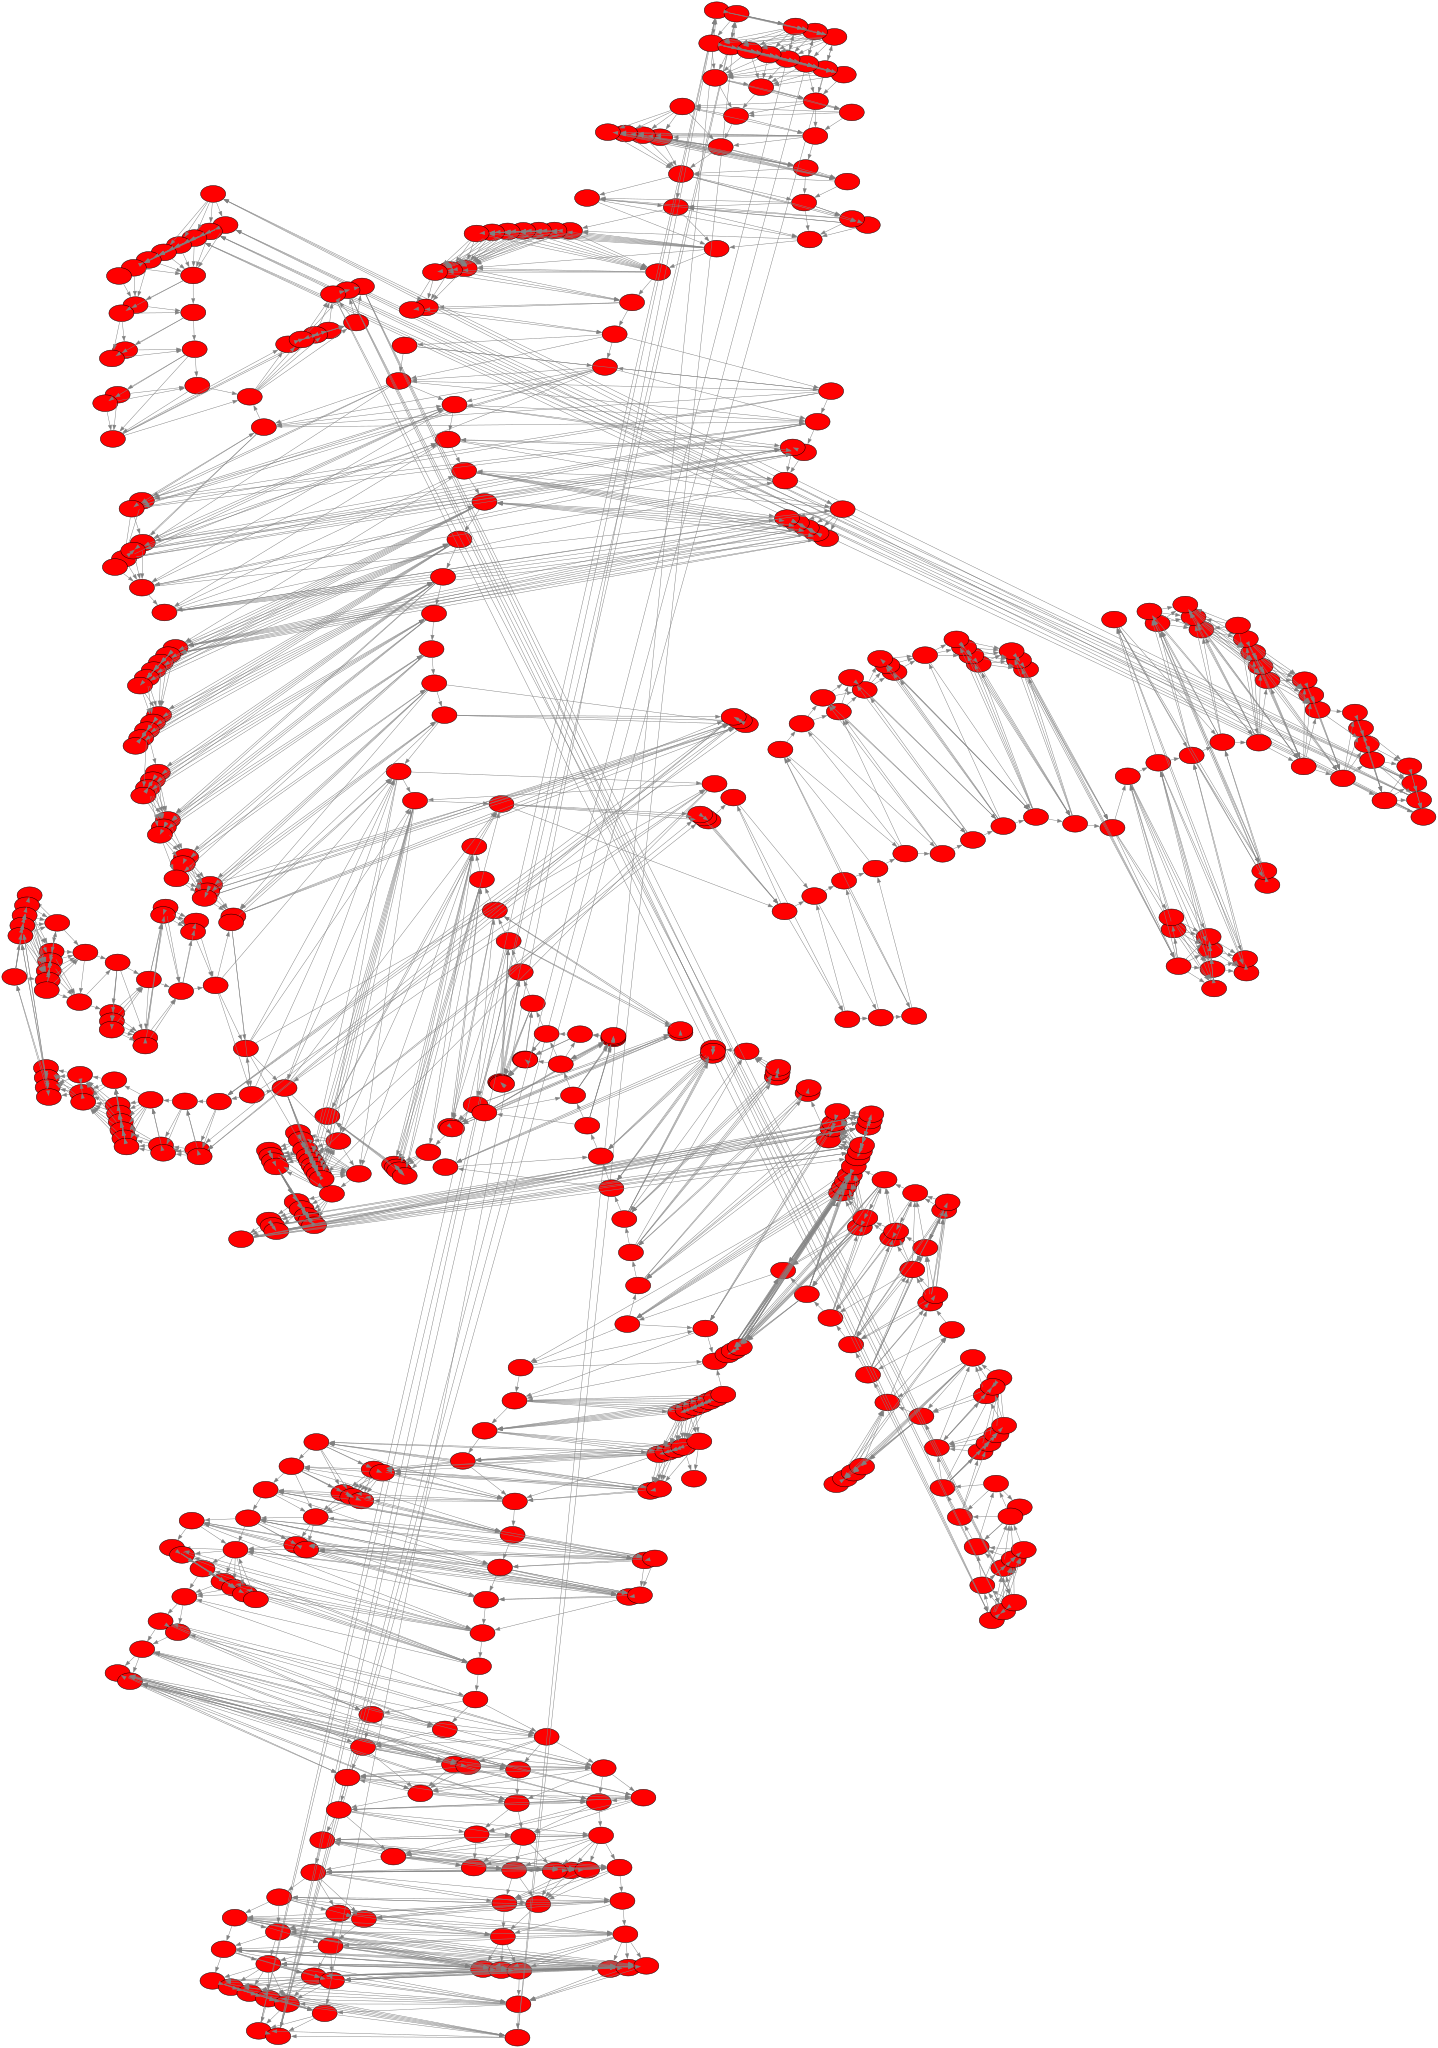

In [4]:
strand_graph_adjacency_matrix = nx.to_numpy_matrix(strand_graph)
print('strand_adjacency_matrix size:', len(strand_graph_adjacency_matrix))

edges = np.argwhere(strand_graph_adjacency_matrix==1).tolist()
nodes = list(strand_graph.nodes)
g = AcyclicGraphDNA.draw_graph(nodes, solve_edges=[], edges=edges)
g.engine = 'twopi'
# g.engine = "fdp"
g

In [5]:
strand_graph_undirected = AcyclicGraphDNA.complement_to_undirected_graph(strand_graph)
adjacency_matrix = nx.to_numpy_matrix(strand_graph_undirected)
part_map, _ , _ = AcyclicGraphDNA.part_graph(cluster_number=1, adjacency_matrix=adjacency_matrix)

graphs = []
node_labels = list(strand_graph_undirected.nodes)
node_lengths = [len(segments[i//2])-len(node_labels[i])-3 for i in range(len(node_labels))]
for part, nodes_indices in part_map.items():
    labels = [node_labels[i] for i in nodes_indices]
    graphs.append(strand_graph.subgraph(labels))

Use the next 3 cells for solving using SA

In [ ]:
solve_edges=[]
split_solutions = []
for pg in graphs:
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()

    Q = AcyclicGraphDNA.to_qubo(adjacency_matrix, A=2)
    target_energy = -2.0*len(adjacency_matrix)+2
    solution = solve_dwave(Q)
    split_solutions.append(solution)

qubo_dict = defaultdict(int)
for i in range(2313):
    for j in range(i, 2313):
        if i==j:
            qubo_dict[(i,)] = Q[i][j]
        else:
            qubo_dict[(i, j)] = Q[i][j]

solutions = [solution[i] for i in range(len(solution)) if i%2==0]

: 

: 

In [ ]:
with open("results-SA-test.pkl", "wb") as f:
    pickle.dump([solutions[0], qubo_dict, solutions[1:]], f)

In [ ]:
scores = [solution[i] for i in range(1, 10000, 2)]
print('min score:', min(scores))
print('avg score:', sum(scores)/len(scores))

Use the next 3 cells for solving using HADOF

Problem device: \
"CPU" runs an ideal simulation of HADOF QAOA \
"fake_backend" runs a simulation of ibm_torino mimicking the device noise \
"real_backend" can be configured with an api code to execute on ibm QPUs

In [ ]:
HADOFrun.hadof_optimiser = "QAOAt"
HADOFrun.num_qubit = 3
HADOFrun.step_layers = 15
HADOFrun.steps = 5
HADOFrun.problem_device = "CPU"

solve_edges=[]
split_solutions = []
for pg in graphs:
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()

    Q = AcyclicGraphDNA.to_qubo(adjacency_matrix, A=2)
    sols = HADOFrun.main(Q)

    # solution = solve_dwave(Q)
    split_solutions.append(sols[2])
    solve_edges_idices=[]
    for i in range(len(Q)):
        if sols[0][i]==1:
            solve_edges_idices.append(edges_indices[i])

    node_labels = list(pg.nodes)
    solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
    solve_edges+=solve_edges_part

Step 1/15, Model: 1
Step 1/15, Model: 2
Step 1/15, Model: 3
Step 1/15, Model: 4
Step 1/15, Model: 5
Step 1/15, Model: 6
Step 1/15, Model: 7
Step 1/15, Model: 8
Step 1/15, Model: 9
Step 1/15, Model: 10
Step 1/15, Model: 11
Step 1/15, Model: 12
Step 1/15, Model: 13
Step 1/15, Model: 14
Step 1/15, Model: 15
Step 1/15, Model: 16
Step 1/15, Model: 17
Step 1/15, Model: 18
Step 1/15, Model: 19
Step 1/15, Model: 20
Step 1/15, Model: 21
Step 1/15, Model: 22
Step 1/15, Model: 23
Step 1/15, Model: 24
Step 1/15, Model: 25
Step 1/15, Model: 26
Step 1/15, Model: 27
Step 1/15, Model: 28
Step 1/15, Model: 29
Step 1/15, Model: 30
Step 1/15, Model: 31
Step 1/15, Model: 32
Step 1/15, Model: 33
Step 1/15, Model: 34
Step 1/15, Model: 35
Step 1/15, Model: 36
Step 1/15, Model: 37
Step 1/15, Model: 38
Step 1/15, Model: 39
Step 1/15, Model: 40
Step 1/15, Model: 41
Step 1/15, Model: 42
Step 1/15, Model: 43
Step 1/15, Model: 44
Step 1/15, Model: 45
Step 1/15, Model: 46
Step 1/15, Model: 47
Step 1/15, Model: 48
S

In [ ]:
with open("results-ideal-HADOF-test.pkl", "wb") as f:
    pickle.dump(sols, f)

In [8]:
scores = []
for i in range(5000):
    var1 = np.array(sols[2][i][:len(Q)])
    var2 = np.array(Q)

    scores.append(var1 @ var2 @ var1)
print('min score:', min(scores))
print('avg score:', sum(scores)/len(scores))

min score: -998.0
avg score: -997.372


To load pre-existing solutions

In [6]:
import dill as pickle
with open("results-real-device.pkl", "rb") as f:
    sols = pickle.load(f)

The next two cells are for visualisation of the solution. \
sol_no can be modified to view a particular sample solution

In [ ]:
sol_no = 0
solve_edges=[]
for num, pg in enumerate(graphs):
    adjacency_matrix = nx.to_numpy_matrix(pg)
    edges_indices = np.argwhere(adjacency_matrix==1).tolist()
    spins, energy = [split_solutions[num][sol_no][i] for i in split_solutions[num][sol_no].keys()], split_solutions[num][sol_no+1]

    solve_edges_idices=[]
    for i in range(len(spins)):
        if spins[i]==1:
            solve_edges_idices.append(edges_indices[i])

    node_labels = list(pg.nodes)
    solve_edges_part = [(node_labels[e[0]], node_labels[e[1]]) for e in solve_edges_idices]
    solve_edges+=solve_edges_part

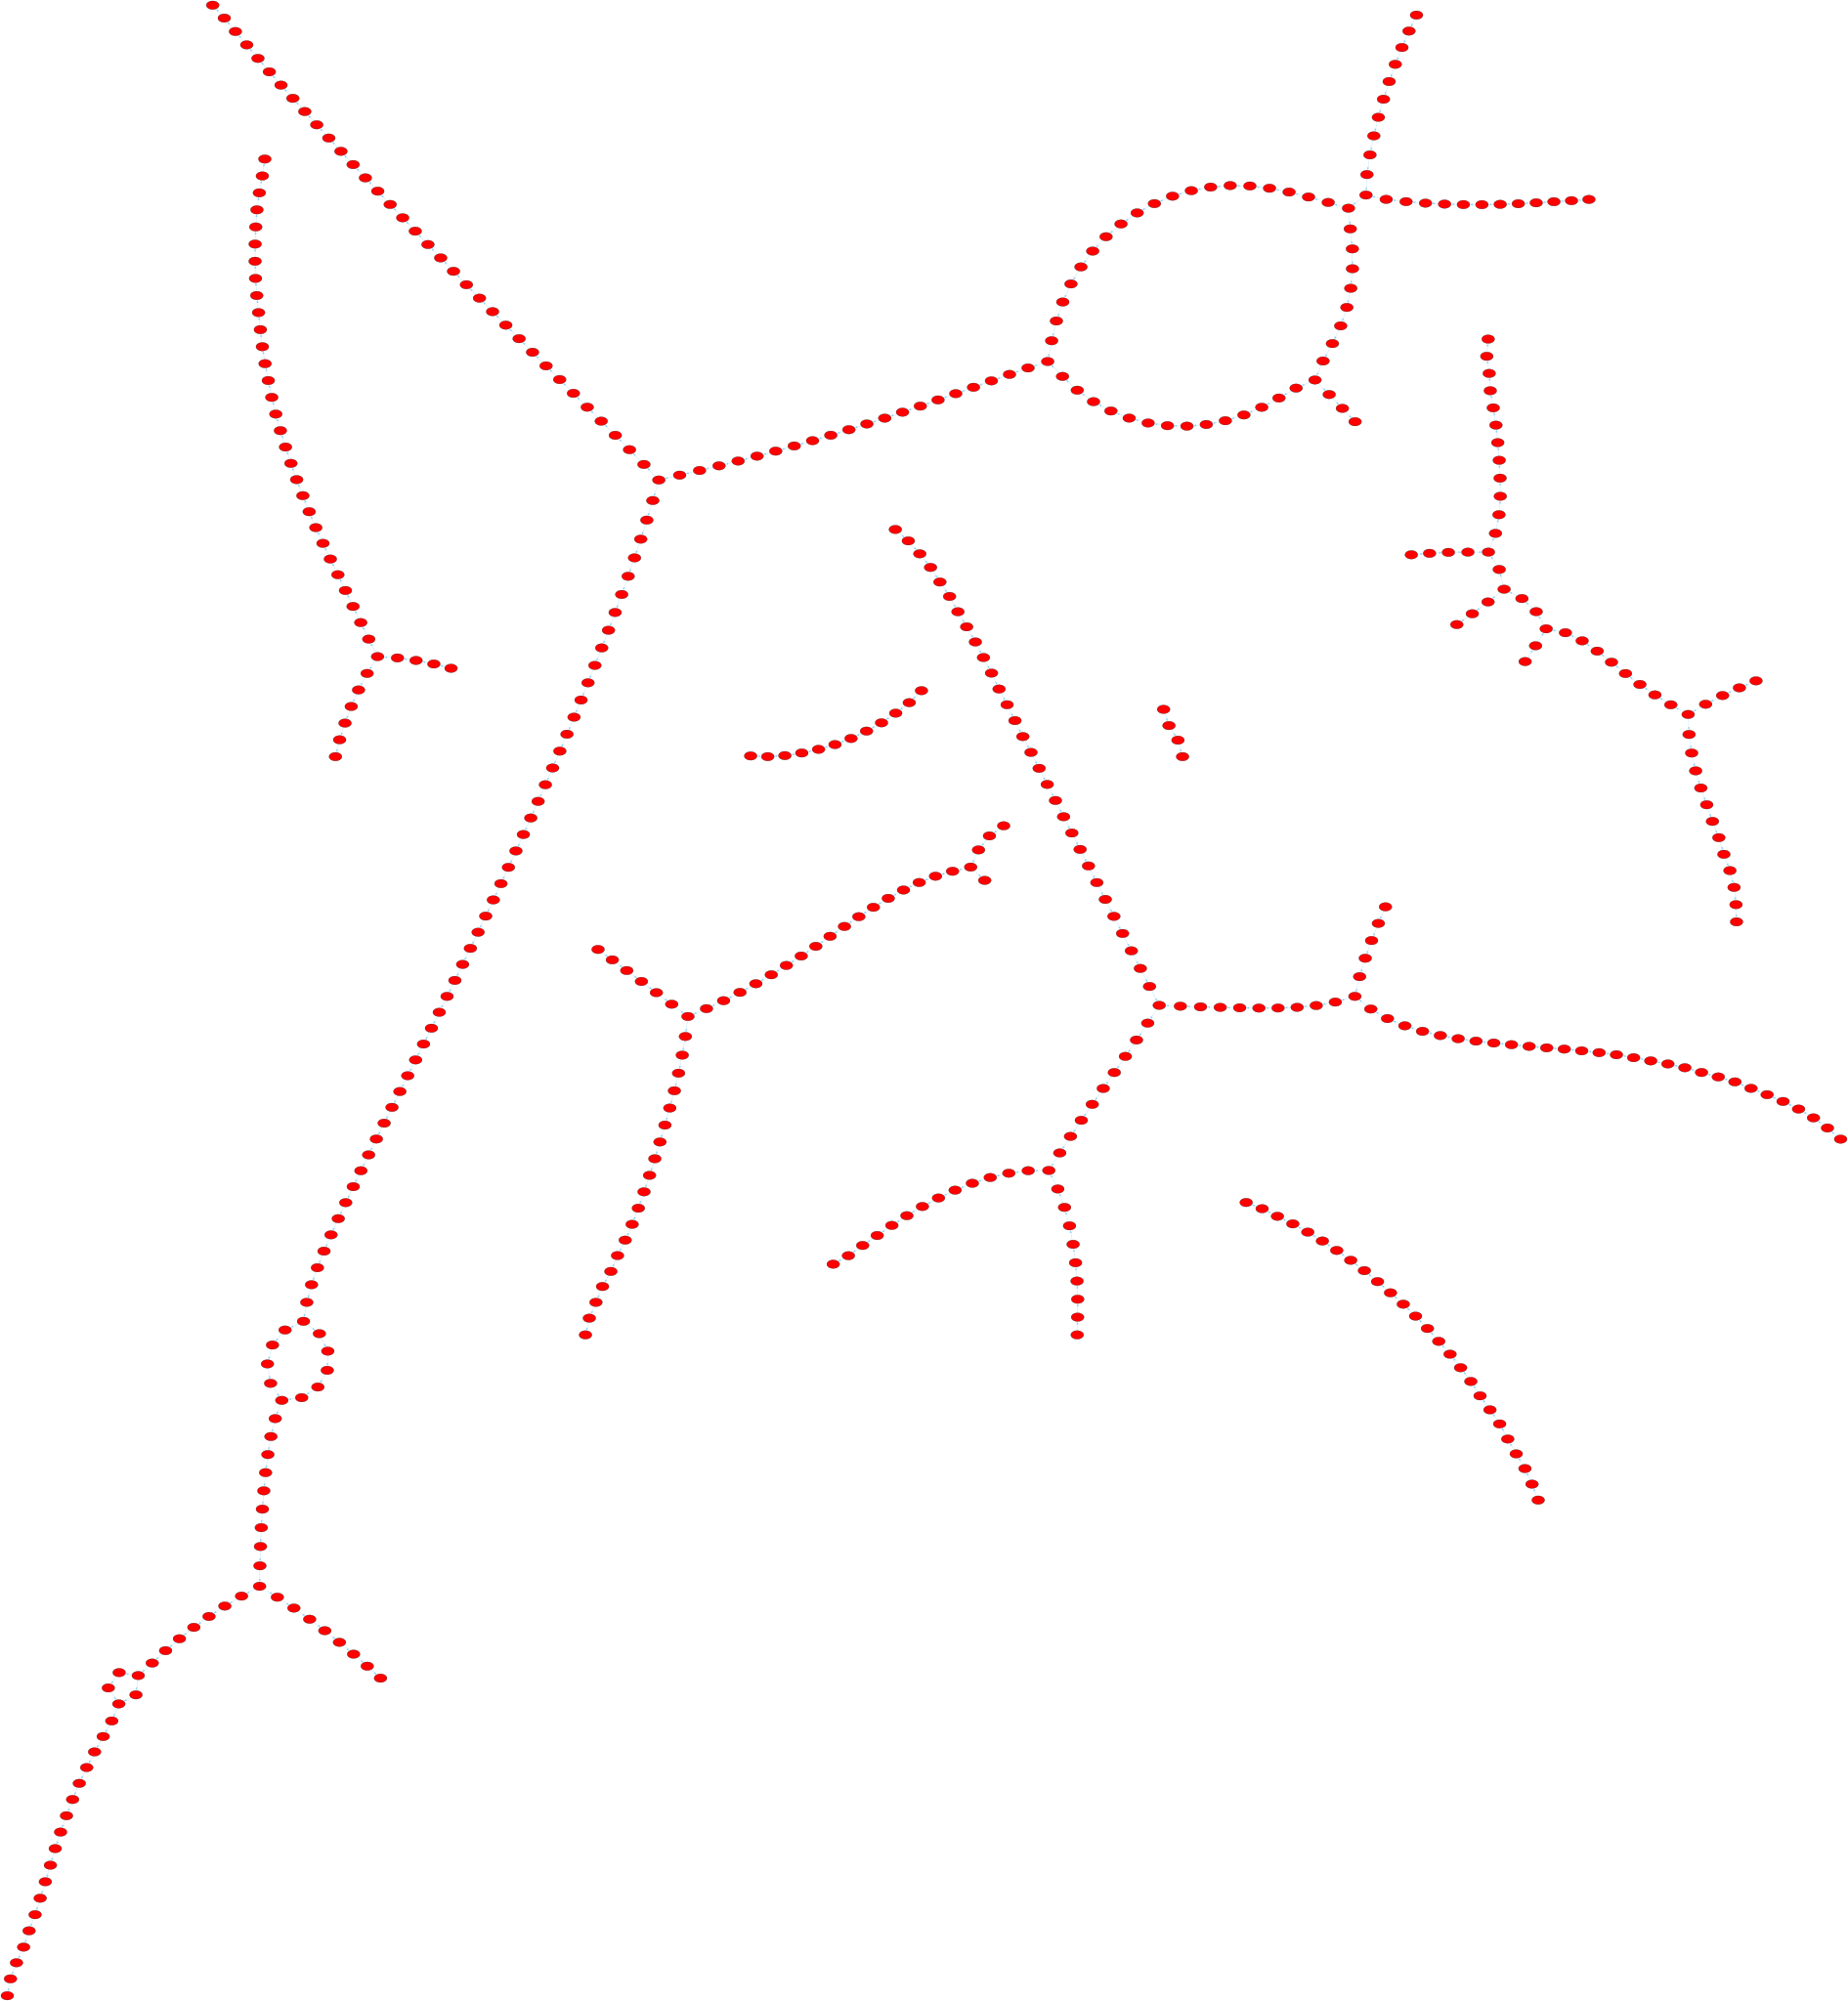

In [9]:
g = AcyclicGraphDNA.draw_solution(graphs, strand_graph, strand_graph_undirected, part_map, solve_edges, show_all_edges=False)
g.engine = 'neato'
g


Post-processing and benchmarking using QUAST

In [7]:
results_file = "results-SA.pkl"

!sed -i '' "s/^RESULTS_PKL=.*/RESULTS_PKL=\"$results_file\"/" run_pipeline_copy.sh
!bash run_pipeline_copy.sh

segments: 524, links: 4642, containments: 0, lines: 5166

nodes quantity: 1048
Processing solution  0
Processing 0
[W] overlap length longer than segment length for 'ERR13577262.3041:1-67620': 67925 > 67620
[M::main] Version: 0.4-r214-dirty
[M::main] CMD: gfatools asm -u output_0.gfa
[M::main] Real time: 0.014 sec; CPU: 0.017 sec
[M::mm_idx_gen::0.075*1.02] collected minimizers
[M::mm_idx_gen::0.090*2.46] sorted minimizers
[M::main::0.090*2.46] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::0.100*2.31] mid_occ = 10
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::0.108*2.21] distinct minimizers: 1102537 (92.03% are singletons); average occurrences: 1.109; average spacing: 5.357; total length: 6552573
[M::worker_pipeline::3.415*8.44] mapped 21969 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -t 16 0_merged_unitigs.fa ERR13577262.fastq
[M::main] Real time: 3.420 sec; CPU: 28.829 sec; Peak RSS: 0.381 GB
[racon::Polisher